In [1]:
import os
import sys
import pickle
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
from util import json2pd,   get_latest_file
from process_data import filter_and_classify, save_distributions, kl_divergence
from scipy.stats import entropy


def plot_distribution_from_cache(cache_file1, cache_file2, output_dir):
    with open(cache_file1, "rb") as f1, open(cache_file2, "rb") as f2:
        cache1 = pickle.load(f1)
        cache2 = pickle.load(f2)

    combined_hist_kde_data1 = cache1["hist_kde_data"]
    combined_hist_kde_data2 = cache2["hist_kde_data"]

    for cache_key in combined_hist_kde_data1.keys():
        if cache_key in combined_hist_kde_data2:
            data1 = combined_hist_kde_data1[cache_key]
            data2 = combined_hist_kde_data2[cache_key]
            vehicle_type, variable = cache_key.split("_")
            plot_distribution_comparison(
                data1, data2, vehicle_type, variable, output_dir
            )


def plot_distribution_comparison(data1, data2, vehicle_type, variable, output_dir):
    hist_data1, bin_width1, bin_centers1, kde_x1, kde_y1 = data1
    hist_data2, bin_width2, bin_centers2, kde_x2, kde_y2 = data2

    plt.figure(figsize=(8, 6))

    # Plot histograms
    plt.bar(
        bin_centers1,
        height=hist_data1,
        width=bin_width1,
        align="center",
        edgecolor="k",
        alpha=0.1,
        color="blue",
        label="Dataset 1 Histogram",
    )
    plt.bar(
        bin_centers2,
        height=hist_data2,
        width=bin_width2,
        align="center",
        edgecolor="k",
        alpha=0.1,
        color="red",
        label="Dataset 2 Histogram",
    )

    # Plot KDEs
    plt.plot(kde_x1, kde_y1, color="blue",
             linestyle="--", label="SUMO Sim KDE")
    plt.plot(kde_x2, kde_y2, color="red",
             linestyle="--", label="Real Field KDE")

    kl_div1_to_2 = entropy(kde_y1, kde_y2)
    kl_div2_to_1 = entropy(kde_y2, kde_y1)

    # Display KL divergence values on the plot
    plt.text(0.05, 0.95, f'KL Div (Dataset 1 || Dataset 2): {kl_div1_to_2:.4f}', 
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.90, f'KL Div (Dataset 2 || Dataset 1): {kl_div2_to_1:.4f}', 
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.title(f"{variable} distribution comparison for {vehicle_type}")
    plt.xlabel(variable)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)

    output_file = os.path.join(
        output_dir, f"{vehicle_type}_{variable}_distribution_comparison.png"
    )
    plt.savefig(output_file)
    plt.show()



from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler

def plot_parallel_coordinates(path=""):
    if not path:
        # Scan "../log" and find the latest .log file
        log_dir = "../log"
        log_files = [f for f in os.listdir(log_dir) if f.endswith(".log")]
        latest_log = max(
            log_files, key=lambda f: os.path.getmtime(os.path.join(log_dir, f))
        )
        path = os.path.join(log_dir, latest_log)

    # Read the log file
    with open(path, "r") as file:
        log_content = file.read()

    # Parse the JSON data
    data_list = [
        json.loads(entry) for entry in log_content.split("\n") if entry.strip()
    ]

    # Create a DataFrame
    df = pd.DataFrame(
        [{**entry["params"], "target": entry["target"]} for entry in data_list]
    )

    # Sort DataFrame by target value
    df = df.sort_values("target")

    # Normalize the parameters to the range [0, 1]
    scaler = MinMaxScaler()
    parameters = [col for col in df.columns if col != "target"]
    df[parameters] = scaler.fit_transform(df[parameters])

    # Create a custom colormap (red to green)
    colors = ["#FF0000", "#00FF04"]
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=n_bins)

    # Normalize target values to [0, 1] for color mapping
    norm = plt.Normalize(df["target"].min(), df["target"].max())

    # Create the parallel coordinates plot with adjusted transparency
    fig, ax = plt.subplots(figsize=(20, 6))
    for i in range(len(df)):
        row = df.iloc[i]
        alpha = 0.1 + 0.2 * norm(row['target'])  # Adjust transparency based on target value
        ax.plot(df.columns[:-1], row[:-1], color=cmap(norm(row['target'])), alpha=alpha)

    # Customize the plot - remove all labels
    ax.set_title("Parallel Coordinates Plot of Parameters vs Target")
    # ax.set_yticklabels([])
    # ax.set_xticklabels([])
    # ax.set_xlabel("")
    ax.set_ylabel("")

    # Add a colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Target Value")

    # Save the figure
    output_dir = "../output"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(
        os.path.join(output_dir, "parallel_coordinates.png"),
        dpi=100,
        bbox_inches="tight",
    )
    plt.show()

def plot_iteration_score(log_path=""):
    if not log_path:
        log_path = get_latest_file(folder="../log", suffix=".log")

    df = json2pd(log_path)
    df["cummax_target"] = df["target"].cummax()
    plt.figure(figsize=(8, 5))
    plt.plot(-df["cummax_target"], label="Cumulative Max Target")
    # plt.plot(-df["target"], label="Current Target", marker="o")
    plt.plot(-df["target"].expanding().mean(), label="Expanding Mean")
    plt.title("Iteration Scores")
    plt.xlabel("Iteration")
    plt.ylabel("Target Score")
    plt.grid(True)

    # Save the figure
    output_path = "../output/plot/iterative_convergence.png"
    plt.savefig(output_path)
    plt.show()
    # plt.close()
# Usage example
if __name__ == "__main__" and not hasattr(sys, 'ps1'):
    plot_iteration_score()
    plot_distribution_from_cache(
        "../output/data_raw/merge/_cache.pkl",
        "../output/data_cache/merge_cache.pkl",
        "../output/plot",
    )
    plot_parallel_coordinates()


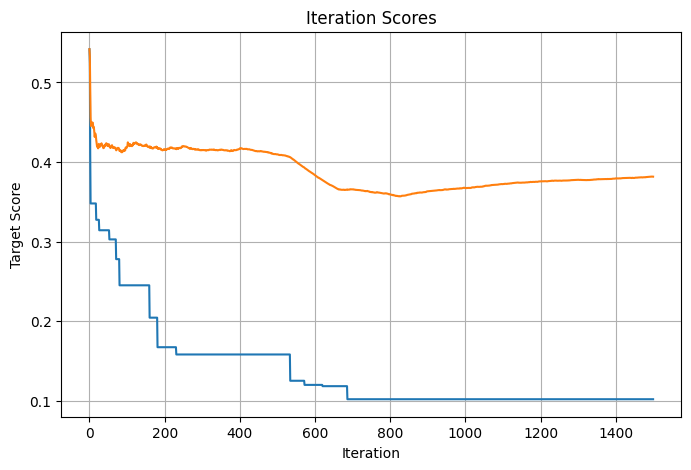

In [12]:
# plot_iteration_score("../log/old.log")
plot_iteration_score()
# plot_parallel_coordinates()

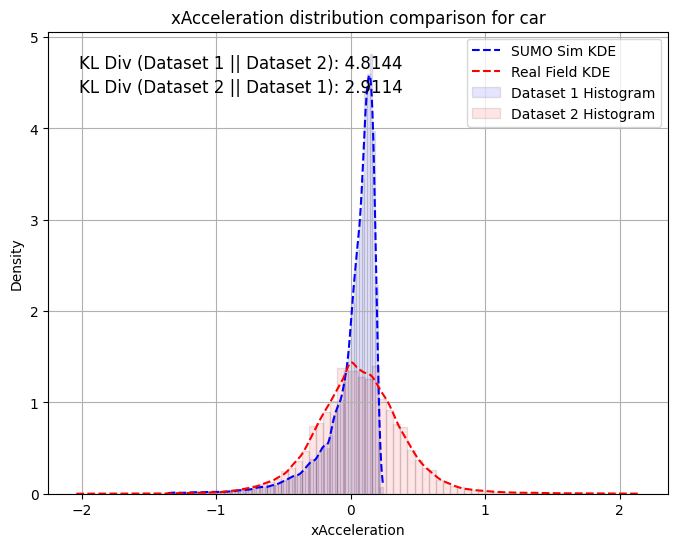

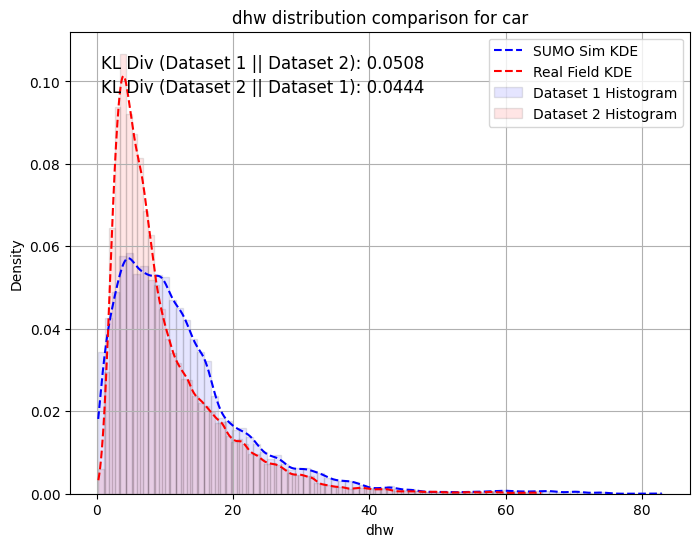

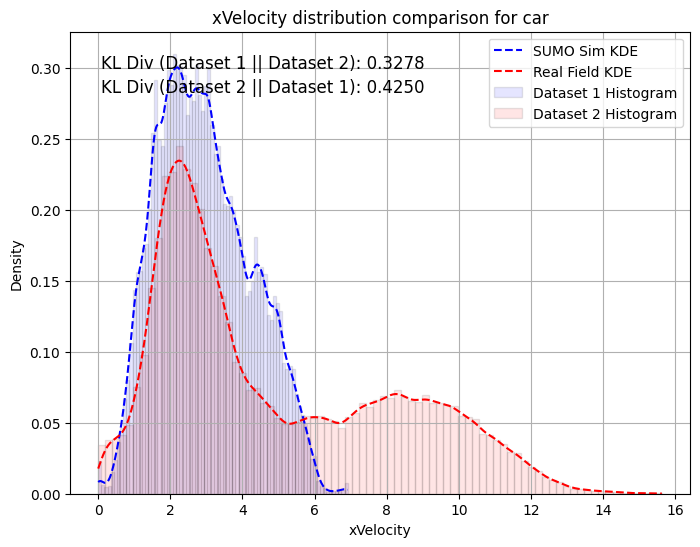

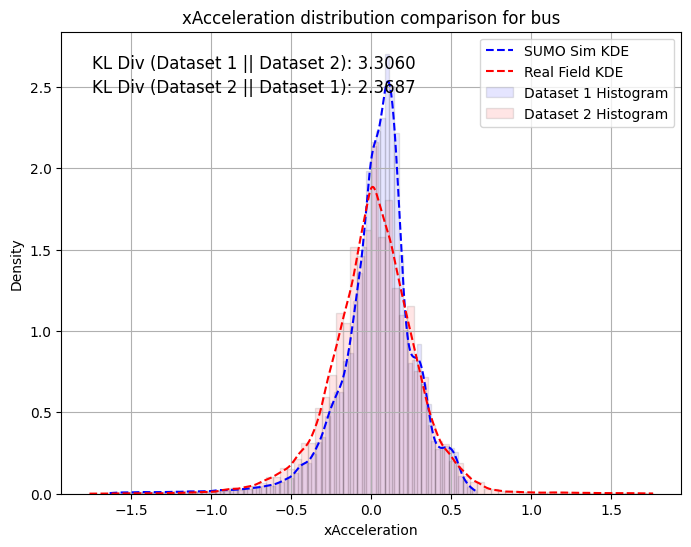

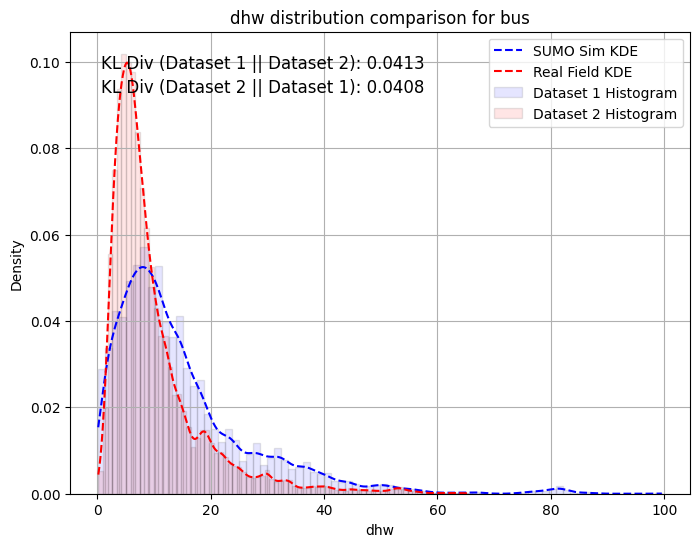

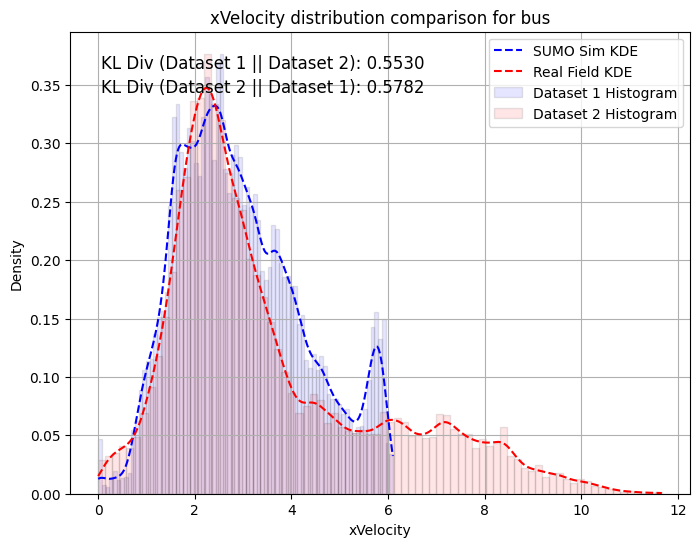

In [13]:

%matplotlib inline
env = "merge"

plot_distribution_from_cache(
    f"../output/data_raw/{env}/_cache.pkl",
    f"../output/data_cache/{env}_cache.pkl",
    "../output/plot",
)